# Prompt Chaining
START -> GEN OUTLINE -> GENERATE BLOG -> END

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(
    model = "openai/gpt-4o-mini",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    max_tokens = 500
)

In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    blog: str

In [5]:
graph = StateGraph(BlogState)

In [6]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # from prompt
    prompt = f"create an outline for given topic to create a blog: {title}"

    # answer 
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [7]:
def create_blog(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']
    outline = state['outline']

    # from prompt
    prompt = f'Generate a blog with title {title} and given outline as: \n {outline}'

    # blog generation 
    blog = model.invoke(prompt).content

    # update state
    state['blog'] = blog

    return state

In [8]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

In [9]:
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

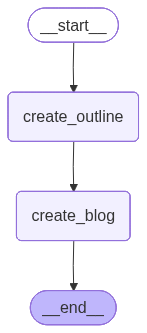

In [10]:
graph.compile()

In [11]:
workflow = graph.compile()

In [12]:
initial_state = {'title': 'rise of AI in India'}

In [13]:
final_state = workflow.invoke(initial_state)

APIStatusError: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 500 tokens, but can only afford 303. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 500 tokens, but can only afford 303. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_2zlXsUIL8oJwLpDuqa2LvUqcQZV'}

In [ ]:
print(final_state)

{'title': 'rise of AI in India', 'outline': "**Blog Outline: The Rise of AI in India**\n\n**I. Introduction**\n   - A. Definition of Artificial Intelligence (AI)\n   - B. Brief overview of the evolution of AI globally\n   - C. Significance of AI in India’s economic and technological landscape\n   \n**II. Historical Context of AI in India**\n   - A. Early developments in AI research in India\n      1. Key institutions and milestones\n      2. Notable pioneers in the field\n   - B. Government initiatives and policies supporting AI\n      1. The National AI Strategy\n      2. Various funding and support programs\n\n**III. Current State of AI in India**\n   - A. Major industries adopting AI technologies\n      1. Information Technology and Software\n      2. Healthcare and Biotechnology\n      3. Finance and Banking\n      4. Agriculture\n      5. Transportation and Logistics\n   - B. Leading AI startups and innovations\n      1. Overview of impactful startups\n      2. Case studies of suc

In [ ]:
print(final_state['outline'])

**Blog Outline: The Rise of AI in India**

**I. Introduction**
   - A. Definition of Artificial Intelligence (AI)
   - B. Brief overview of the evolution of AI globally
   - C. Significance of AI in India’s economic and technological landscape
   
**II. Historical Context of AI in India**
   - A. Early developments in AI research in India
      1. Key institutions and milestones
      2. Notable pioneers in the field
   - B. Government initiatives and policies supporting AI
      1. The National AI Strategy
      2. Various funding and support programs

**III. Current State of AI in India**
   - A. Major industries adopting AI technologies
      1. Information Technology and Software
      2. Healthcare and Biotechnology
      3. Finance and Banking
      4. Agriculture
      5. Transportation and Logistics
   - B. Leading AI startups and innovations
      1. Overview of impactful startups
      2. Case studies of successful AI implementation
   - C. Educational institutions and AI res

In [ ]:
print(final_state['blog'])

# The Rise of AI in India

## I. Introduction
Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, particularly computer systems. These processes include learning, reasoning, and self-correction. Over the past few decades, AI has evolved from theoretical concepts to practical applications that permeate various aspects of daily life and industry. As global giants like the USA and China lead the charge in AI advancements, India is rapidly emerging as a significant player in this technological revolution. With its vast pool of skilled talent, a burgeoning startup ecosystem, and supportive government policies, AI is poised to reshape India's economic and technological landscape in unprecedented ways.

## II. Historical Context of AI in India
### A. Early developments in AI research in India
The journey of AI in India dates back to the 1980s when pioneering institutions began exploring the implications of AI technologies. The Indian Statistical 